# SCAR

### Finding Source from closed corpus - with only target + its concepts
### Finding Source (with concepts) from closed corpus - with only target + its concepts 
###  Finding Source (with concepts) from closed corpus - with only target + its concepts   (not mapped) 

### `Extraction of data`

In [2]:
import pandas as pd
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')

In [3]:
df_scar.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


### `Finding Source from closed corpus - with only target`

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm.notebook import tqdm
import json
import time

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Loaded SCAR dataset: {len(df_scar)} analogies")
print(f"Unique targets (system_a): {df_scar['system_a'].nunique()}")
print(f"Unique sources (system_b): {df_scar['system_b'].nunique()}")


Loaded SCAR dataset: 400 analogies
Unique targets (system_a): 321
Unique sources (system_b): 333


## Configuration

Set up API keys and test parameters


In [13]:
# Configuration
import os
from dotenv import load_dotenv

# Load environment variables (if using .env file)
load_dotenv('../../.env')

# Test configuration
TEST_MODE = True  # Set to False to run on full dataset
TEST_SAMPLE_SIZE = 10  # Number of examples to test
TOP_K = 10  # Number of top results to retrieve

# Tournament configuration
TOURNAMENT_BATCH_SIZE = 150 

# Models to test (start with 2)
TEST_MODELS = [
    "gpt-4.1-mini",  # OpenAI
    "meta-llama-3-1-70b-instruct",  # DeepInfra
]

# Results directory
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Test Mode: {TEST_MODE}")
if TEST_MODE:
    print(f"Sample Size: {TEST_SAMPLE_SIZE}")
print(f"Top-K: {TOP_K}")
print(f"Tournament Batch Size: {TOURNAMENT_BATCH_SIZE}")
print(f"Models: {TEST_MODELS}")


Test Mode: True
Sample Size: 10
Top-K: 10
Tournament Batch Size: 150
Models: ['gpt-4.1-mini', 'meta-llama-3-1-70b-instruct']


## Method 1: RAG-Based Source Finding

Using OpenAI embeddings and cosine similarity to find analogous sources


In [6]:
# Initialize RAG Source Finder
from rag_source_finder import RAGSourceFinder

print("Initializing RAG Source Finder...")
rag_finder = RAGSourceFinder()

# Load corpus
print("Loading corpus...")
rag_finder.load_corpus_from_csv('../../data/SCAR_cleaned_manually.csv')

# Embed corpus (this will take a moment)
print("Embedding corpus (this may take a minute)...")
rag_finder.embed_corpus()

print("RAG finder ready!")


Initializing RAG Source Finder...
Loading corpus...
Loaded 333 unique sources from corpus
Embedding corpus (this may take a minute)...
Generating embeddings for corpus...
Generated 333 embeddings
RAG finder ready!


In [7]:
# Run RAG evaluation
print("Running RAG evaluation...")
sample_size = TEST_SAMPLE_SIZE if TEST_MODE else None

rag_results = rag_finder.evaluate_on_dataset(
    '../../data/SCAR_cleaned_manually.csv',
    top_k=TOP_K,
    sample_size=sample_size
)

print(f"\nCompleted! Evaluated {len(rag_results)} examples")

# Display sample results
print("\n" + "="*80)
print("Sample RAG Results (first 5):")
print("="*80)
for idx, row in rag_results.head().iterrows():
    print(f"\nTarget: {row['target']}")
    print(f"Gold Source: {row['gold_source']}")
    print(f"Predicted (Rank 1): {row['predicted_rank_1']}")
    print(f"Gold Rank: {row['gold_rank']}")
    print(f"Top 3 sources: {row['top_k_sources'][:3]}")

# Save results
rag_results_path = os.path.join(RESULTS_DIR, "rag_results.csv")
rag_results.to_csv(rag_results_path, index=False)
print(f"\nSaved RAG results to {rag_results_path}")


Running RAG evaluation...
Evaluating on 10 examples...
Processed 210/10 examples
Processed 330/10 examples

Completed! Evaluated 10 examples

Sample RAG Results (first 5):

Target: Westernization Movement
Gold Source: Reform Movement of 1898
Predicted (Rank 1): New Culture Movement
Gold Rank: 3
Top 3 sources: ['New Culture Movement', 'Enlightenment', 'Reform Movement of 1898']

Target: household
Gold Source: government
Predicted (Rank 1): house
Gold Rank: -1
Top 3 sources: ['house', 'Houses', 'family']

Target: Cell division
Gold Source: the replicator
Predicted (Rank 1): life
Gold Rank: -1
Top 3 sources: ['life', 'Biological Evolution', 'Evolution']

Target: Westernization Movement
Gold Source: The Revolution of 1911
Predicted (Rank 1): New Culture Movement
Gold Rank: -1
Top 3 sources: ['New Culture Movement', 'Enlightenment', 'marriage']

Target: Electrochemical Reaction
Gold Source: Power Generation
Predicted (Rank 1): Chemical Reactions
Gold Rank: 5
Top 3 sources: ['Chemical Reacti

## Method 2: Tournament-Style Iterative Elimination

LLM-based tournament where sources compete in batches


In [14]:
# Import modules
sys.path.append('../mapping_generation')
from easy_llm_importer import LLMClient
from iterative_source_finder import TournamentSourceFinder

# Initialize LLM client
print("Initializing LLM client...")
llm_client = LLMClient()

# Prepare source candidates from corpus
print("Preparing source corpus...")
source_candidates = []
seen_sources = set()

for _, row in df_scar.iterrows():
    source_name = row['system_b']
    if source_name not in seen_sources:
        source_candidates.append({
            'name': source_name,
            'description': row['system_b_background'],
            'domain': row['system_b_domain']
        })
        seen_sources.add(source_name)

print(f"Prepared {len(source_candidates)} unique source candidates")

# Get test data
test_data = df_scar.sample(n=TEST_SAMPLE_SIZE, random_state=42) if TEST_MODE else df_scar
print(f"Testing on {len(test_data)} examples")


Initializing LLM client...
Preparing source corpus...
Prepared 333 unique source candidates
Testing on 10 examples


In [15]:
# Run Tournament for each test model
tournament_results_all = {}

for model_name in TEST_MODELS:
    print(f"\n{'='*80}")
    print(f"Running Tournament with model: {model_name}")
    print('='*80)
    
    tournament_finder = TournamentSourceFinder(
        llm_client=llm_client,
        model_name=model_name,
        batch_size=TOURNAMENT_BATCH_SIZE
    )
    
    model_results = []
    
    for idx, row in test_data.iterrows():
        target_name = row['system_a']
        target_bg = row['system_a_background']
        gold_source = row['system_b']
        
        print(f"\n[{idx+1}/{len(test_data)}] Target: {target_name}")
        
        # Run tournament
        result = tournament_finder.find_source(
            target_name=target_name,
            target_background=target_bg,
            source_candidates=source_candidates
        )
        
        # Store results
        model_results.append({
            'id': row['id'],
            'target': target_name,
            'gold_source': gold_source,
            'predicted_source': result.predicted_source,
            'num_rounds': len(result.rounds),
            'num_llm_calls': result.total_llm_calls,
            'time_seconds': result.total_time,
            'reasoning': result.rounds[-1].reasoning if result.rounds else ""
        })
    
    # Convert to DataFrame
    tournament_results_all[model_name] = pd.DataFrame(model_results)
    
    # Save
    save_path = os.path.join(RESULTS_DIR, f"tournament_{model_name.replace('/', '_')}.csv")
    tournament_results_all[model_name].to_csv(save_path, index=False)
    print(f"\nSaved tournament results to {save_path}")
    
    # Quick stats
    correct = (tournament_results_all[model_name]['predicted_source'] == 
               tournament_results_all[model_name]['gold_source']).sum()
    accuracy = correct / len(tournament_results_all[model_name])
    print(f"\nAccuracy: {accuracy:.2%} ({correct}/{len(tournament_results_all[model_name])})")



Running Tournament with model: gpt-4.1-mini

[210/10] Target: Westernization Movement

Tournament for target: Westernization Movement
Starting with 333 candidates

=== Round 1 ===
Candidates: 333
  Batch 1/3: 150 sources
    Winner: engine
  Batch 2/3: 150 sources
    Winner: Meiji Restoration in Japan
  Batch 3/3: 33 sources
    Winner: Group Behavior

=== Round 2 ===
Candidates: 3
  Batch 1/1: 3 sources
    Winner: Meiji Restoration in Japan

Final Winner: Meiji Restoration in Japan
Total rounds: 2
Total LLM calls: 4
Total time: 12.95s

[281/10] Target: household

Tournament for target: household
Starting with 333 candidates

=== Round 1 ===
Candidates: 333
  Batch 1/3: 150 sources
    Winner: engine
  Batch 2/3: 150 sources
    Winner: Feudal Dynasties
  Batch 3/3: 33 sources
    Winner: Human Relationships

=== Round 2 ===
Candidates: 3
  Batch 1/1: 3 sources
    Winner: Feudal Dynasties

Final Winner: Feudal Dynasties
Total rounds: 2
Total LLM calls: 4
Total time: 11.03s

[34/10]

## Evaluation and Comparison

Compare all methods with comprehensive metrics


In [16]:
# Import evaluator
from evaluate_source_finding import SourceFindingEvaluator, print_metrics_table

evaluator = SourceFindingEvaluator()

# Collect all metrics
all_metrics = []

# 1. Evaluate RAG
print("Evaluating RAG results...")
rag_metrics = evaluator.evaluate_rag_results(rag_results, method_name="RAG")
all_metrics.append(rag_metrics)

# 2. Evaluate Tournament for each model
for model_name in TEST_MODELS:
    print(f"Evaluating Tournament - {model_name}...")
    tournament_metrics = evaluator.evaluate_iterative_results(
        tournament_results_all[model_name],
        method_name="Tournament",
        model_name=model_name
    )
    all_metrics.append(tournament_metrics)

print("\nEvaluation complete!")


Evaluating RAG results...
Evaluating Tournament - gpt-4.1-mini...
Evaluating Tournament - meta-llama-3-1-70b-instruct...

Evaluation complete!


In [17]:
# Create comparison table
comparison_df = evaluator.compare_methods(all_metrics)

# Display results
print_metrics_table(comparison_df)

# Save comparison
comparison_path = os.path.join(RESULTS_DIR, "comparison_metrics.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"\nSaved comparison to {comparison_path}")



SOURCE FINDING EVALUATION RESULTS

    method                       model exact_match_acc top_1_acc top_3_acc top_5_acc top_10_acc   mrr avg_rank  num_samples
       RAG                        None            0.0%      0.0%     20.0%     30.0%      30.0%  8.7%     3.67           10
Tournament                gpt-4.1-mini           10.0%     10.0%     10.0%     10.0%      10.0% 10.0%    -1.00           10
Tournament meta-llama-3-1-70b-instruct           10.0%     10.0%     10.0%     10.0%      10.0% 10.0%    -1.00           10



Saved comparison to results\comparison_metrics.csv


Saved visualization to results\comparison_visualization.png


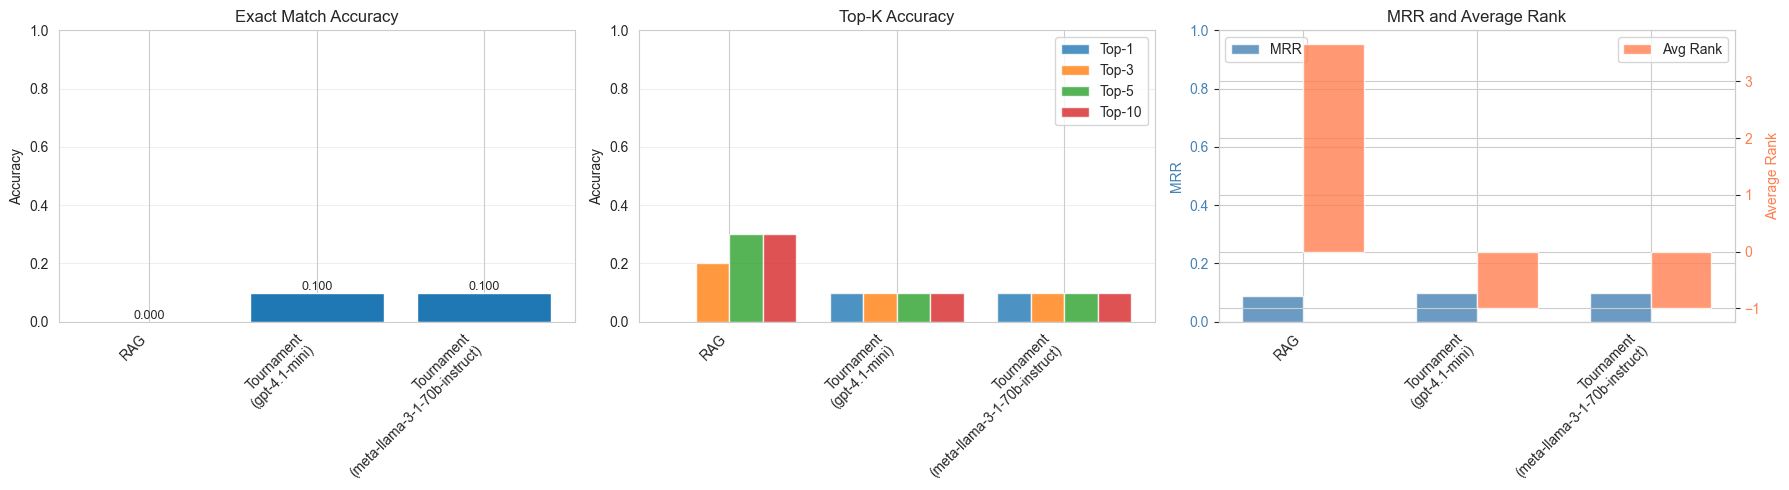

In [18]:
# Visualize comparison
viz_path = os.path.join(RESULTS_DIR, "comparison_visualization.png")
evaluator.visualize_comparison(comparison_df, save_path=viz_path)


## Performance Analysis

Analyze time, LLM calls, and efficiency


In [ ]:
# Performance metrics for Tournament method
performance_data = []

for model_name in TEST_MODELS:
    # Tournament
    t_df = tournament_results_all[model_name]
    performance_data.append({
        'Method': 'Tournament',
        'Model': model_name,
        'Avg LLM Calls': t_df['num_llm_calls'].mean(),
        'Avg Time (s)': t_df['time_seconds'].mean(),
        'Total Time (s)': t_df['time_seconds'].sum(),
    })

performance_df = pd.DataFrame(performance_data)
print("\n" + "="*80)
print("PERFORMANCE METRICS - TOURNAMENT")
print("="*80)
print(performance_df.to_string(index=False))
print("\n" + "="*80)

# Note: RAG is much faster (embedding-based, no LLM calls per query after initial embedding)



PERFORMANCE METRICS - TOURNAMENT
    Method                       Model  Avg LLM Calls  Avg Time (s)  Total Time (s)
Tournament                gpt-4.1-mini            4.0     12.721371      127.213710
Tournament meta-llama-3-1-70b-instruct            4.0     49.855589      498.555886



## Model Reasoning Analysis

Examine the reasoning provided by LLMs for their choices


In [27]:
# Show sample reasoning from Tournament method
print("="*80)
print("SAMPLE REASONING FROM TOURNAMENT METHOD")
print("="*80)

# Pick first model and first example
sample_model = TEST_MODELS[0]

print(f"\n### Tournament - {sample_model} ###\n")
sample_tournament = tournament_results_all[sample_model].iloc[4]
print(f"Target: {sample_tournament['target']}")
print(f"Gold Source: {sample_tournament['gold_source']}")
print(f"Predicted: {sample_tournament['predicted_source']}")
print(f"Match: {'✓' if sample_tournament['predicted_source'] == sample_tournament['gold_source'] else '✗'}")
print(f"\nReasoning:\n{sample_tournament['reasoning']}")

print("\n" + "="*80)


SAMPLE REASONING FROM TOURNAMENT METHOD

### Tournament - gpt-4.1-mini ###

Target: Electrochemical Reaction
Gold Source: Power Generation
Predicted: Circuits
Match: ✗

Reasoning:
Electrochemical reactions fundamentally rely on the flow of electrons through a conductive pathway, analogous to how electric circuits enable electron flow through interconnected components. Both involve the transfer of charge via a conductive medium (wires or electrolyte) between distinct points (electrodes or circuit nodes), making circuits the best structural and conceptual analogy for understanding electron transfer and the role of conductivity in electrochemical processes.

